In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from core.GraphCreator import GraphCreator
import networkx as nx
from core.PlotGraph import plotGraph

In [38]:
output = pd.read_csv("output.csv")
inputs = pd.read_csv("config/atomicInputs.csv")
inputs.set_index("node", inplace=True)
display(output)

,node,SCT
0,crystal_chronicles:bronchus_planks,2.375
1,suppsquared:item_shelf_jungle,1.188
2,born_in_chaos_v1:great_reaper_axe,30610.000
3,protection_pixel:hellsnakeas_chestplate,6102.444
4,sophisticatedstorage:diamond_to_netherite_tier...,99.288
...,...,...
3494,minecraft:hay_block,540.000
3495,#zinc_ores,50.000
3496,create:raw_zinc_block,450.000
3497,#dark_metal_ores,800.000


# Outliers

In [37]:
display(output[output["SCT"] > 1e5])

,node,SCT
415,hazennstuff:radiance,126362.343
522,hazennstuff:advanced,156501.687
690,hazennstuff:reinforced,120701.753
926,hazennstuff:abomination,232378.290
1225,born_in_chaos_v1:darkwarblade,130505.000
1238,hazennstuff:strengthened,217627.396
1987,hazennstuff:singularity,223287.986
2376,hazennstuff:sacred,145599.207
2560,hazennstuff:absolute,238038.880


In [16]:
with open('fullGraph.gpickle', 'rb') as f:
    gc : GraphCreator = pickle.load(f)

In [19]:
for node,data in gc.G.nodes.data():
    if data["type"] == "cycle":
        for subnode in data["subgraph"].nodes:
            if subnode == "irons_spellbooks:invisibility_elixir":
                print(node)

cycle-81


In [22]:
plotGraph(gc.G.nodes["cycle-81"]["subgraph"], "cycle-invisibility", fixedInOut=False)

cycle-invisibility.html


In [39]:
inputs.loc["#logs"]

value                  9.5
cycle                  NaN
representative         NaN
partition         part-000
Name: #logs, dtype: object

# Distribution

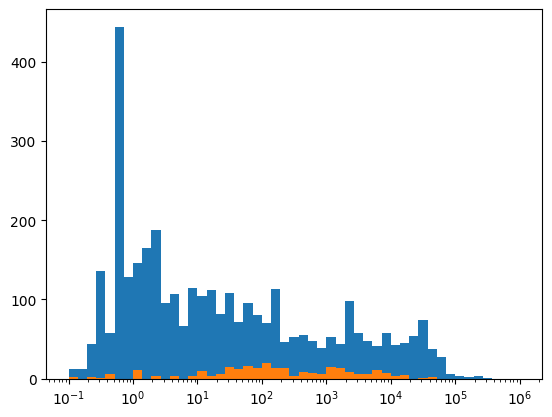

In [33]:
plt.figure()
plt.hist(output['SCT'],bins=np.geomspace(0.1, 1e6, 50))
plt.hist(inputs['value'],bins=np.geomspace(0.1, 1e6, 50))
plt.xscale('log')
plt.show()